# 01 – Data Collection
**Examensarbete – Bull & Bear Market Detection**  
Viktor Emilsson & Loran Ali, Örebro Universitet 2026

---

I den här notebooken hämtar vi daglig OHLCV-data för:
- **S&P 500** (`^GSPC`) – amerikanskt aktieindex
- **Bitcoin** (`BTC-USD`) – kryptovaluta
- **Guld** (`GC=F`) – råvara / safe-haven tillgång

**Period:** 2014-01-01 → 2026-01-01  
**Källa:** Yahoo Finance via `yfinance`

## 1. Importera bibliotek

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Plottinställningar
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('✓ Bibliotek importerade')

✓ Bibliotek importerade


## 2. Definiera tillgångar och tidsperiod

In [2]:
TICKERS = {
    'SP500':   '^GSPC',
    'Bitcoin': 'BTC-USD',
    'Gold':    'GC=F',
}

START = '2014-01-01'
END   = '2026-01-01'

DATA_DIR = '../data'
os.makedirs(DATA_DIR, exist_ok=True)

print(f'Tillgångar : {list(TICKERS.keys())}')
print(f'Period     : {START} → {END}')
print(f'Data-mapp  : {DATA_DIR}')

Tillgångar : ['SP500', 'Bitcoin', 'Gold']
Period     : 2014-01-01 → 2026-01-01
Data-mapp  : ../data


## 3. Hämta data från Yahoo Finance

Vi hämtar alla tillgängliga variabler (OHLCV):
- **Open** – öppningspris
- **High** – dagens högsta pris
- **Low** – dagens lägsta pris
- **Close** – stängningspris
- **Volume** – handelsvolym

In [3]:
from curl_cffi import requests as curl_requests

session = curl_requests.Session(impersonate="chrome")

def fetch_asset(name, ticker, start, end, retries=5, wait=60):
    """Hämtar OHLCV-data för en tillgång med automatiska återförsök."""
    for attempt in range(retries):
        try:
            t = yf.Ticker(ticker, session=session)
            df = t.history(start=start, end=end, auto_adjust=True)
            if len(df) > 0:
                if isinstance(df.columns, pd.MultiIndex):
                    df.columns = df.columns.get_level_values(0)
                df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
                df.index.name = 'Date'
                df.index = pd.to_datetime(df.index).tz_localize(None)
                return df
            else:
                print(f'  Försök {attempt+1}/{retries} – tom data, väntar {wait}s...')
                time.sleep(wait)
        except Exception as e:
            print(f'  Försök {attempt+1}/{retries} – fel: {e}, väntar {wait}s...')
            time.sleep(wait)
    return pd.DataFrame()

print('Funktion redo.')


Funktion redo.


In [4]:
# Hämta alla tillgångar
assets = {}

for name, ticker in TICKERS.items():
    print(f'\nHämtar {name} ({ticker})...')
    df = fetch_asset(name, ticker, START, END)
    
    if not df.empty:
        assets[name] = df
        print(f'  ✓ {len(df)} rader')
        print(f'  ✓ Period: {df.index.min().date()} → {df.index.max().date()}')
        print(f'  ✓ Kolumner: {list(df.columns)}')
    else:
        print(f'  ✗ Misslyckades')
    
    time.sleep(10)

print(f'\n✓ Hämtade {len(assets)}/3 tillgångar')


Hämtar SP500 (^GSPC)...
  ✓ 3018 rader
  ✓ Period: 2014-01-02 → 2025-12-31
  ✓ Kolumner: ['Open', 'High', 'Low', 'Close', 'Volume']

Hämtar Bitcoin (BTC-USD)...
  ✓ 4124 rader
  ✓ Period: 2014-09-17 → 2025-12-31
  ✓ Kolumner: ['Open', 'High', 'Low', 'Close', 'Volume']

Hämtar Gold (GC=F)...
  ✓ 3017 rader
  ✓ Period: 2014-01-02 → 2025-12-31
  ✓ Kolumner: ['Open', 'High', 'Low', 'Close', 'Volume']

✓ Hämtade 3/3 tillgångar


## 4. Utforska datan

In [5]:
# Visa första raderna för varje tillgång
for name, df in assets.items():
    print(f'\n── {name} ──────────────────────────────────')
    display(df.head())


── SP500 ──────────────────────────────────


,Open,High,Low,Close,Volume
Date,,,,,
2014-01-02,1845.859985,1845.859985,1827.739990,1831.979980,3080600000
2014-01-03,1833.209961,1838.239990,1829.130005,1831.369995,2774270000
2014-01-06,1832.310059,1837.160034,1823.729980,1826.770020,3294850000
2014-01-07,1828.709961,1840.099976,1828.709961,1837.880005,3511750000
2014-01-08,1837.900024,1840.020020,1831.400024,1837.489990,3652140000



── Bitcoin ──────────────────────────────────


,Open,High,Low,Close,Volume
Date,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100



── Gold ──────────────────────────────────


,Open,High,Low,Close,Volume
Date,,,,,
2014-01-02,1204.300049,1227.300049,1204.300049,1225.000000,209
2014-01-03,1221.699951,1239.000000,1221.699951,1238.400024,142
2014-01-06,1232.800049,1247.000000,1221.900024,1237.800049,127
2014-01-07,1239.300049,1242.400024,1226.300049,1229.400024,73
2014-01-08,1227.500000,1227.500000,1218.599976,1225.300049,189


In [6]:
# Statistik för varje tillgång
for name, df in assets.items():
    print(f'\n── {name} – Statistik ──────────────────────')
    display(df.describe().round(2))


── SP500 – Statistik ──────────────────────


,Open,High,Low,Close,Volume
count,3018.00,3018.00,3018.00,3018.00,3.018000e+03
mean,3473.57,3491.83,3453.83,3474.13,4.043852e+09
std,1353.05,1359.85,1345.71,1353.25,1.006061e+09
min,1743.82,1755.79,1737.92,1741.89,0.000000e+00
25%,2267.05,2271.84,2258.26,2264.14,3.406532e+09
50%,3004.17,3016.19,2989.73,3004.28,3.835995e+09
75%,4380.85,4409.62,4356.07,4379.80,4.466820e+09
max,6936.02,6945.77,6921.60,6932.05,9.976520e+09



── Bitcoin – Statistik ──────────────────────


,Open,High,Low,Close,Volume
count,4124.00,4124.00,4124.00,4124.00,4.124000e+03
mean,26828.25,27368.67,26257.64,26848.34,2.163072e+10
std,31639.83,32181.99,31062.43,31650.55,2.288509e+10
min,176.90,211.73,171.51,178.10,5.914570e+06
25%,2690.98,2771.03,2613.84,2701.33,1.286307e+09
50%,10762.84,11022.06,10442.99,10765.19,1.708105e+10
75%,42200.93,43017.27,41396.10,42236.83,3.317551e+10
max,124752.14,126198.07,123196.05,124752.53,3.509679e+11



── Gold – Statistik ──────────────────────


,Open,High,Low,Close,Volume
count,3017.00,3017.00,3017.00,3017.00,3017.00
mean,1728.76,1737.72,1720.33,1729.25,5135.73
std,651.73,657.22,647.29,652.75,28050.43
min,1053.70,1062.00,1046.20,1050.80,0.00
25%,1264.10,1269.60,1258.50,1264.50,51.00
50%,1537.50,1546.70,1518.00,1526.60,196.00
75%,1920.10,1927.80,1911.70,1919.10,610.00
max,4512.00,4556.30,4502.00,4529.10,386334.00


In [7]:
# Saknade värden
print('── Saknade värden ──────────────────────────')
for name, df in assets.items():
    missing = df.isnull().sum()
    print(f'\n{name}:')
    print(missing)

── Saknade värden ──────────────────────────

SP500:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Bitcoin:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Gold:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


## 5. Visualisera stängningspriser

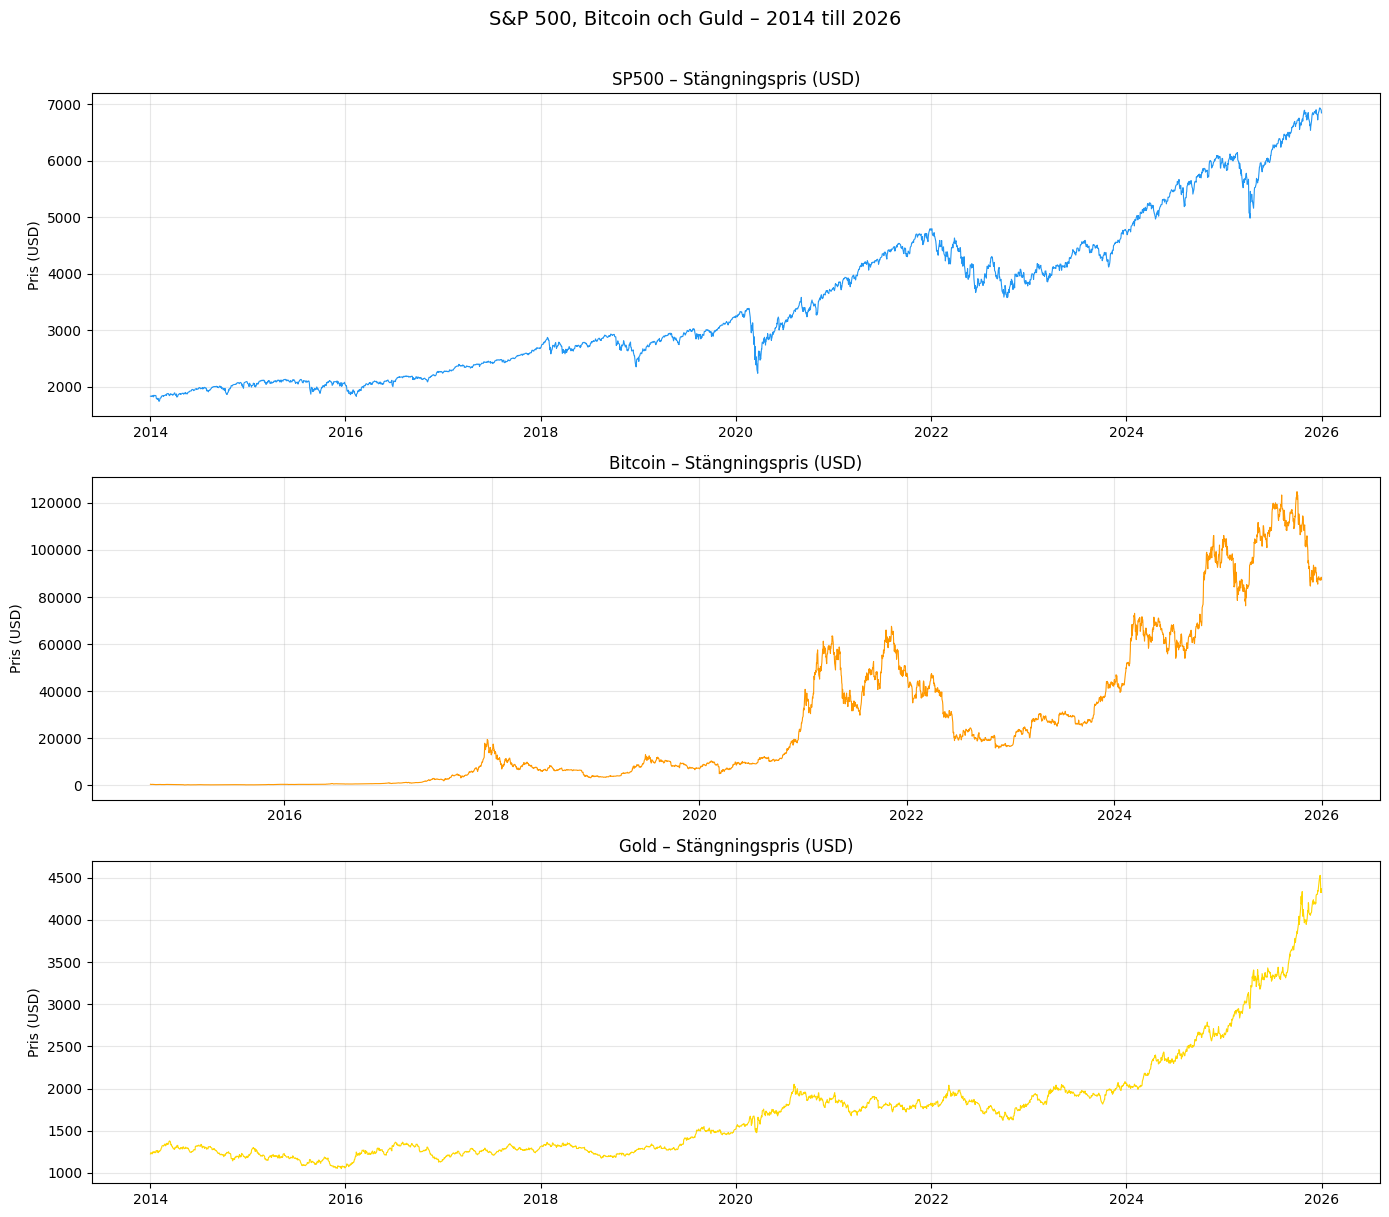

✓ Graf sparad: results/01_close_prices.png


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

colors = {'SP500': '#2196F3', 'Bitcoin': '#FF9800', 'Gold': '#FFD700'}

for ax, (name, df) in zip(axes, assets.items()):
    ax.plot(df.index, df['Close'], color=colors[name], linewidth=0.8)
    ax.set_title(f'{name} – Stängningspris (USD)', fontsize=12)
    ax.set_ylabel('Pris (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('S&P 500, Bitcoin och Guld – 2014 till 2026', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/01_close_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/01_close_prices.png')

## Normaliserad prisutveckling

För att jämföra tillgångarnas prisutveckling normaliserar vi alla priser 
till startindex = 100 (januari 2014). Y-axeln visar alltså procentuell 
förändring relativt startpunkten – ett värde på 300 betyder att tillgången 
tredubblats sedan start.



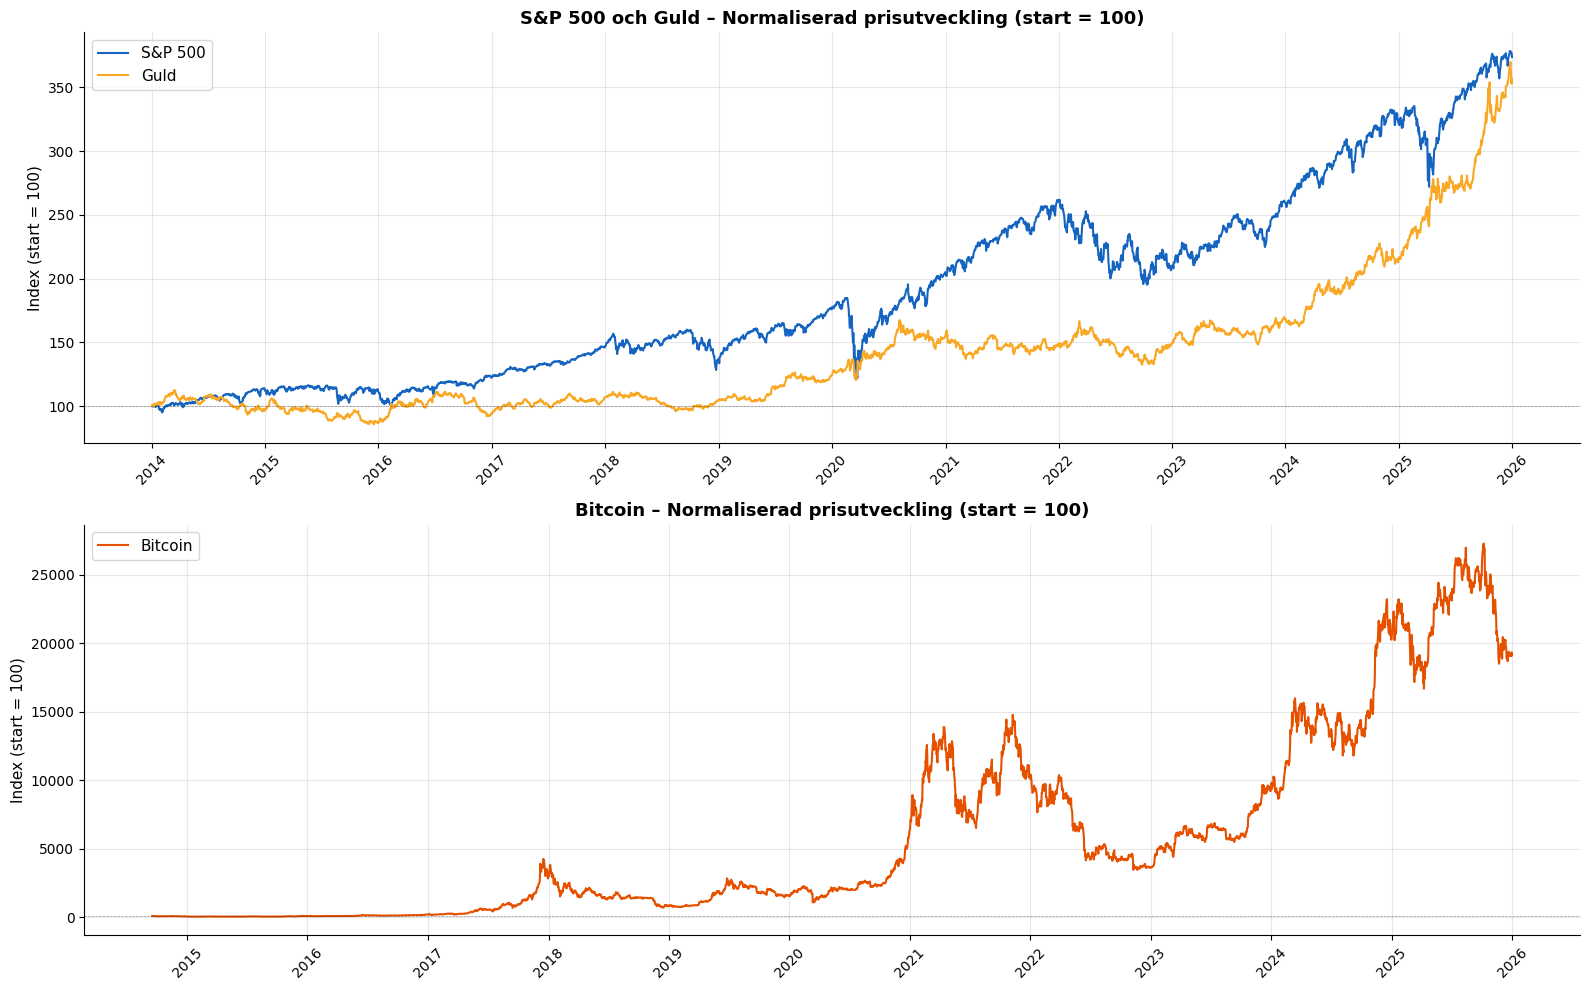

In [9]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

colors = {'SP500': '#1565C0', 'Bitcoin': '#E65100', 'Gold': '#F9A825'}
labels = {'SP500': 'S&P 500', 'Bitcoin': 'Bitcoin', 'Gold': 'Guld'}

# Övre graf: S&P 500 och Guld
for name in ['SP500', 'Gold']:
    df = assets[name]
    close = df['Close'].dropna()
    normalized = (close / close.iloc[0]) * 100
    ax1.plot(normalized.index, normalized, label=labels[name],
             color=colors[name], linewidth=1.5)

ax1.set_title('S&P 500 och Guld – Normaliserad prisutveckling (start = 100)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Index (start = 100)', fontsize=11)
ax1.axhline(100, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
ax1.legend(fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Nedre graf: Bitcoin ensam
close_btc = assets['Bitcoin']['Close'].dropna()
normalized_btc = (close_btc / close_btc.iloc[0]) * 100
ax2.plot(normalized_btc.index, normalized_btc, label='Bitcoin',
         color=colors['Bitcoin'], linewidth=1.5)

ax2.set_title('Bitcoin – Normaliserad prisutveckling (start = 100)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Index (start = 100)', fontsize=11)
ax2.axhline(100, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
ax2.legend(fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/01_normalized_prices.png', dpi=150, bbox_inches='tight')
plt.show()

Vi delar upp i två separata grafer eftersom Bitcoins extrema tillväxt 
(~27 000% sedan 2014) gör det omöjligt att visa alla tre i samma graf – 
S&P 500 och Guld skulle synas knappt. Separata grafer ger en tydligare bild av:

- **S&P 500 och Guld** – stabil tillväxt med tydliga nedgångar vid kriser
- **Bitcoin** – extrem volatilitet med tydliga bull/bear-cykler

## 6. Spara data

In [11]:
os.makedirs('../results', exist_ok=True)

# Spara separata filer
for name, df in assets.items():
    filename = f'{name.lower()}.csv'
    filepath = os.path.join(DATA_DIR, filename)
    df.to_csv(filepath)
    print(f'✓ Sparad: data/{filename}  ({len(df)} rader)')

# Spara kombinerad fil
dfs_prefixed = []
for name, df in assets.items():
    df_p = df.copy()
    df_p.columns = [f'{name}_{col}' for col in df.columns]
    dfs_prefixed.append(df_p)

combined = pd.concat(dfs_prefixed, axis=1, sort=True)
combined.index.name = 'Date'
combined.to_csv(os.path.join(DATA_DIR, 'raw_prices.csv'))
print(f'\n✓ Kombinerad fil: data/raw_prices.csv')
print(f'  {combined.shape[0]} rader × {combined.shape[1]} kolumner')

✓ Sparad: data/sp500.csv  (3018 rader)
✓ Sparad: data/bitcoin.csv  (4124 rader)
✓ Sparad: data/gold.csv  (3017 rader)

✓ Kombinerad fil: data/raw_prices.csv
  4302 rader × 15 kolumner


## 7. Sammanfattning

| Tillgång | Ticker | Rader | Period | Variabler |
|----------|--------|-------|--------|-----------|
| S&P 500 | ^GSPC | ~3018 | 2014–2026 | Open, High, Low, Close, Volume |
| Bitcoin | BTC-USD | ~4124 | 2014–2026 | Open, High, Low, Close, Volume |
| Guld | GC=F | ~3017 | 2014–2026 | Open, High, Low, Close, Volume |

**Notering om saknade värden:**  
S&P 500 och Guld handlas bara på vardagar, Bitcoin handlas 7 dagar/vecka. 
Det innebär att det finns fler rader för Bitcoin. Detta hanteras i nästa notebook när vi slår ihop datan och droppar NaN.

**Nästa steg:** `02_labeling.ipynb` – skapa bull/bear-etiketter med 20%-regeln.